In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as stats
import seaborn as sns
import numpy as np

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [25]:
# 데이터 불러오기
df = pd.read_csv('./data/Courses.csv', parse_dates=['start_time_DI', 'last_event_DI'])
df.head()
# index 컬럼 제거 -> 의미 없음
# final_cc_cname_DI 컬럼 Other~~ 들 필요시 병합
# roles 컬럼 제거 -> 컬럼 전체가 결측치
# start_time_DI, last_event_DI 날짜형


,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0


In [3]:
print(df.shape)
print(df.dtypes)

(641138, 21)
index                         int64
course_id                       str
userid_DI                       str
registered                    int64
viewed                        int64
explored                      int64
certified                     int64
final_cc_cname_DI               str
LoE_DI                          str
YoB                         float64
gender                          str
grade                           str
start_time_DI        datetime64[us]
last_event_DI        datetime64[us]
nevents                     float64
ndays_act                   float64
nplay_video                 float64
nchapters                   float64
nforum_posts                  int64
roles                       float64
incomplete_flag             float64
dtype: object


In [4]:
# 결측치 개수, 비율
display(pd.DataFrame({
    'sum': df.isna().sum(),
    'ratio': df.isna().mean() * 100
}).sort_values('ratio', ascending=False).reset_index())

,index,sum,ratio
0,roles,641138,100.000000
1,incomplete_flag,540977,84.377622
2,nplay_video,457530,71.362172
3,nchapters,258753,40.358394
4,nevents,199151,31.062111
5,last_event_DI,178954,27.911932
6,ndays_act,162743,25.383459
7,LoE_DI,106008,16.534350
8,YoB,96605,15.067739
9,gender,86806,13.539363


In [27]:
# 전처리용 데이터 셋 생성
pre = df.copy()

In [26]:
df['final_cc_cname_DI'].value_counts()

final_cc_cname_DI
United States                             184240
India                                      88696
Unknown/Other                              82029
Other Europe                               40377
Other Africa                               23897
United Kingdom                             22131
Brazil                                     17856
Other Middle East/Central Asia             17325
Other South Asia                           12992
Canada                                     12738
Pakistan                                   10824
Russian Federation                         10432
Spain                                      10003
Other South America                         9916
Egypt                                       9286
Germany                                     8074
Nigeria                                     7483
Other East Asia                             6446
Australia                                   6419
Mexico                                      5638
Ph

In [6]:
# 중복행 확인
len(pre.duplicated())

641138

In [16]:
pre['grade'].value_counts().sort_index()

grade
False    148260
True     492878
Name: count, dtype: int64

In [ ]:

pre['course'] = pre['course_id'].str.split('/').str[1]

In [9]:
pre['course'].value_counts()

course
CS50x     169621
6.00x     124446
6.002x     63046
ER22x      57406
PH207x     41592
PH278x     39602
8.02x      31048
CB22x      30002
14.73x     27870
7.00x      21009
3.091x     20354
8.MReV      9477
2.01x       5665
Name: count, dtype: int64

In [ ]:
pre['start_time_DI'].value_counts()

start_time_DI
2012-08-17    10165
2013-01-23     8368
2012-10-15     6766
2012-08-16     6369
2012-12-20     5858
2013-02-14     5810
2012-12-21     5809
2012-08-18     5531
2012-08-13     5247
2013-03-03     5053
2012-10-16     4639
2012-07-24     4635
2013-02-15     4436
2013-01-22     4263
2012-08-20     4107
2012-10-03     3885
2012-10-14     3683
2013-01-24     3493
2012-09-04     3432
2013-02-12     3409
2012-08-21     3381
2012-08-19     3375
2012-07-25     3356
2013-02-21     3344
2012-09-05     3334
2012-09-12     3325
2013-02-04     3315
2013-01-31     3290
2012-10-17     3106
2013-02-18     3076
2012-09-06     3057
2012-10-01     3028
2013-01-15     3011
2013-02-05     3003
2013-01-30     2974
2013-03-04     2958
2013-02-20     2947
2012-10-02     2916
2012-08-12     2883
2013-02-19     2862
2013-03-06     2859
2013-02-27     2856
2013-03-12     2833
2013-02-03     2792
2013-01-28     2782
2012-08-22     2767
2013-02-11     2751
2013-02-22     2725
2012-09-11     2677
2013-0

In [10]:
pre['course_id'].value_counts()

course_id
HarvardX/CS50x/2012            169621
MITx/6.00x/2012_Fall            66731
MITx/6.00x/2013_Spring          57715
HarvardX/ER22x/2013_Spring      57406
HarvardX/PH207x/2012_Fall       41592
MITx/6.002x/2012_Fall           40811
HarvardX/PH278x/2013_Spring     39602
MITx/8.02x/2013_Spring          31048
HarvardX/CB22x/2013_Spring      30002
MITx/14.73x/2013_Spring         27870
MITx/6.002x/2013_Spring         22235
MITx/7.00x/2013_Spring          21009
MITx/3.091x/2012_Fall           14215
MITx/8.MReV/2013_Summer          9477
MITx/3.091x/2013_Spring          6139
MITx/2.01x/2013_Spring           5665
Name: count, dtype: int64

In [11]:
pre[
    (pre['course_id']=='HarvardX/PH278x/2013_Spring') &
    (pre['certified'] == 1)
]['grade'].value_counts().sort_index()

grade
False    711
Name: count, dtype: int64

In [12]:
pre['course_id'].unique()

<StringArray>
[ 'HarvardX/CB22x/2013_Spring',         'HarvardX/CS50x/2012',
  'HarvardX/ER22x/2013_Spring',   'HarvardX/PH207x/2012_Fall',
 'HarvardX/PH278x/2013_Spring',       'MITx/6.002x/2012_Fall',
     'MITx/6.002x/2013_Spring',     'MITx/14.73x/2013_Spring',
      'MITx/2.01x/2013_Spring',       'MITx/3.091x/2012_Fall',
     'MITx/3.091x/2013_Spring',        'MITx/6.00x/2012_Fall',
      'MITx/6.00x/2013_Spring',      'MITx/7.00x/2013_Spring',
      'MITx/8.02x/2013_Spring',     'MITx/8.MReV/2013_Summer']
Length: 16, dtype: str

In [13]:
# 결측치 개수, 비율
pd.DataFrame({
    'sum': pre.isna().sum(),
    'ratio': pre.isna().mean() * 100
}).sort_values('ratio', ascending=False)

,sum,ratio
roles,641138,100.000000
incomplete_flag,540977,84.377622
nplay_video,457530,71.362172
nchapters,258753,40.358394
nevents,199151,31.062111
last_event_DI,178954,27.911932
ndays_act,162743,25.383459
LoE_DI,106008,16.534350
YoB,96605,15.067739
gender,86806,13.539363


In [36]:
# 활동 기간
pre['activity_period']= (pre['last_event_DI'] - pre['start_time_DI']).dt.days
display(pre['activity_period'].value_counts().sort_index())
display(pre['ndays_act'].value_counts().sort_index())
display(pre[pre['activity_period']< 0]['course_id'].value_counts())
# 활동기간을 활용해서 실제 활동 일수와 뭔가를 만들어 볼 수 있지 않을까..!

activity_period
-381.0         1
-361.0         1
-357.0         2
-355.0         1
-352.0         1
-346.0         1
-344.0         1
-343.0         1
-336.0         1
-335.0         1
-332.0         1
-317.0         1
-311.0         2
-308.0         1
-306.0         1
-303.0         2
-297.0         1
-295.0         1
-294.0         1
-289.0         1
-286.0         1
-285.0         1
-284.0         1
-283.0         1
-281.0         2
-279.0         2
-278.0         1
-277.0         1
-276.0         1
-275.0         1
-273.0         3
-272.0         2
-270.0         2
-269.0         1
-268.0         1
-267.0         1
-266.0         1
-264.0         1
-262.0         1
-261.0         1
-259.0         1
-258.0         3
-257.0         1
-256.0         2
-255.0         1
-253.0         2
-252.0         1
-249.0         1
-248.0         1
-247.0         1
-246.0         6
-245.0         1
-244.0         1
-242.0         2
-241.0         2
-240.0         1
-238.0         1
-237.0         

ndays_act
1.0      209941
2.0       80625
3.0       43081
4.0       26813
5.0       18552
6.0       13239
7.0       10281
8.0        8075
9.0        6510
10.0       5324
11.0       4415
12.0       3815
13.0       3323
14.0       2794
15.0       2542
16.0       2146
17.0       2002
18.0       1852
19.0       1564
20.0       1497
21.0       1339
22.0       1309
23.0       1207
24.0       1093
25.0       1027
26.0        947
27.0        887
28.0        891
29.0        838
30.0        806
31.0        771
32.0        710
33.0        652
34.0        639
35.0        617
36.0        600
37.0        537
38.0        525
39.0        520
40.0        517
41.0        522
42.0        486
43.0        516
44.0        429
45.0        454
46.0        436
47.0        374
48.0        405
49.0        387
50.0        394
51.0        371
52.0        309
53.0        306
54.0        328
55.0        360
56.0        308
57.0        288
58.0        279
59.0        279
60.0        274
61.0        261
62.0        21

course_id
HarvardX/CS50x/2012            292
MITx/6.00x/2013_Spring         239
MITx/6.002x/2013_Spring        169
HarvardX/PH207x/2012_Fall      161
MITx/6.002x/2012_Fall          141
MITx/8.02x/2013_Spring         114
HarvardX/ER22x/2013_Spring      85
MITx/14.73x/2013_Spring         47
HarvardX/CB22x/2013_Spring      41
MITx/3.091x/2013_Spring         37
HarvardX/PH278x/2013_Spring     36
MITx/6.00x/2012_Fall            27
MITx/8.MReV/2013_Summer         22
MITx/7.00x/2013_Spring          15
MITx/3.091x/2012_Fall           13
MITx/2.01x/2013_Spring           4
Name: count, dtype: int64

In [38]:
# 파생 컬럼 생성

# 학생들의 나이(Age)
pre['Age'] = pre['start_time_DI'].dt.year - pre['YoB']

# Age 결측치 플래깅(Age_missing)
pre['Age_missing'] = pre['Age'].isna().astype('int64')

# 참여 단계 컬럼(step): 각 학생 별 진행 단계
pre['step'] = np.select(
    [
        pre['certified'] ==1,
        pre['explored'] == 1,
        pre['viewed'] == 1,
        pre['registered'] == 1,
    ],
    [
        'Certified',
        'Explored',
        'Viewed',
        'Registered'
    ],
    default='None'
)

# 활동 기간
pre['activity_period']= pre['last_event_DI'] - pre['start_time_DI']
pre['activity_period'].head()




0   333 days
1        NaT
2   282 days
3        NaT
4        NaT
Name: activity_period, dtype: timedelta64[us]

In [ ]:
pre['activity']

In [ ]:
display(pre.groupby('step')[['nevents', 'ndays_act','nplay_video','nchapters','nforum_posts']].agg(['count', 'median', 'sum']).reset_index())

step nevents                     ndays_act                    \
                count  median         sum     count median        sum   
0   Certified   17675  4513.0  91260780.0     17675   43.0   829148.0   
1    Explored   20653   731.0  36172631.0     20892   14.0   410021.0   
2  Registered  117774     2.0    367563.0    142782    1.0   261025.0   
3      Viewed  285885    49.0  62698967.0    297046    2.0  1231563.0   

  nplay_video                   nchapters                  nforum_posts  \
        count median        sum     count median       sum        count   
0       13306  418.0  8826828.0     17687   16.0  295626.0        17687   
1       10653  219.0  4280271.0     22689   12.0  273107.0        22689   
2         126    2.0      388.0      2932    1.0    6320.0       240868   
3      159523   14.0  7978822.0    339077    2.0  814696.0       359894   

                
  median   sum  
0    0.0  3736  
1    0.0  1560  
2    0.0    50  
3    0.0  6815

In [ ]:
display(pre.groupby('step')[['nplay_video']].agg(['count', 'median', 'sum', 'min', 'max']).reset_index())
display(pre.groupby('step')[['nchapters']].agg(['count', 'median', 'sum', 'min', 'max']).reset_index())

step nplay_video                                
                    count median        sum  min      max
0   Certified       13043  419.0  8675372.0  1.0  19179.0
1    Explored       10436  219.0  4195199.0  1.0  34596.0
2  Registered         124    2.0      382.0  1.0     38.0
3      Viewed      154914   14.0  7762838.0  1.0  98517.0

step nchapters                            
                  count median       sum  min   max
0   Certified     17182   16.0  286388.0  1.0  48.0
1    Explored     21948   12.0  264645.0  6.0  48.0
2  Registered      2862    1.0    6171.0  1.0  34.0
3      Viewed    326880    2.0  785743.0  1.0  48.0

In [40]:
pre[
    (pre['nevents'].isna()) &
    (pre['step']=='Certified')
]

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag,activity_period,Age,Age_missing,step
106843,106843,HarvardX/CS50x/2012,MHxPC130306856,1,1,1,1,Unknown/Other,Doctorate,1968.0,m,1,2012-11-30,NaT,NaN,NaN,NaN,12.0,0,NaN,1.0,NaT,44.0,0,Certified
144691,144691,HarvardX/PH207x/2012_Fall,MHxPC130033009,1,1,1,1,Other South Asia,Master's,1975.0,m,0.96,2012-10-17,NaT,NaN,NaN,NaN,15.0,0,NaN,1.0,NaT,37.0,0,Certified
213275,213275,HarvardX/PH278x/2013_Spring,MHxPC130522075,1,1,1,1,Unknown/Other,Secondary,1993.0,m,0.81,2013-03-17,NaT,NaN,NaN,NaN,10.0,0,NaN,1.0,NaT,20.0,0,Certified
252887,252887,HarvardX/PH278x/2013_Spring,MHxPC130410256,1,1,1,1,Other South Asia,Secondary,1992.0,m,0.81,2013-03-01,NaT,NaN,NaN,NaN,9.0,0,NaN,1.0,NaT,21.0,0,Certified
319145,319145,HarvardX/ER22x/2013_Spring,MHxPC130328116,1,1,1,1,Unknown/Other,Secondary,1994.0,m,0.69,2013-06-23,NaT,NaN,NaN,NaN,31.0,0,NaN,1.0,NaT,19.0,0,Certified
325969,325969,HarvardX/ER22x/2013_Spring,MHxPC130095114,1,1,0,1,Unknown/Other,Secondary,1993.0,m,1,2013-07-22,NaT,NaN,NaN,NaN,8.0,0,NaN,1.0,NaT,20.0,0,Certified
396575,396575,MITx/6.00x/2012_Fall,MHxPC130292274,1,1,1,1,Unknown/Other,NaN,NaN,m,0.6,2012-08-13,NaT,NaN,NaN,NaN,17.0,0,NaN,1.0,NaT,NaN,1,Certified
462248,462248,MITx/6.00x/2012_Fall,MHxPC130383454,1,1,1,1,Unknown/Other,Secondary,1993.0,m,0.63,2012-10-01,NaT,NaN,NaN,NaN,9.0,0,NaN,1.0,NaT,19.0,0,Certified
514799,514799,MITx/6.002x/2013_Spring,MHxPC130276145,1,1,1,1,India,Secondary,1992.0,m,0.77,2012-12-27,NaT,NaN,NaN,NaN,17.0,1,NaN,1.0,NaT,20.0,0,Certified
547604,547604,MITx/7.00x/2013_Spring,MHxPC130043740,1,1,1,1,Unknown/Other,Bachelor's,1989.0,f,0.69,2013-03-12,NaT,NaN,NaN,NaN,13.0,0,NaN,1.0,NaT,24.0,0,Certified


In [20]:
display(pre.groupby('step').agg(['count']).reset_index())

,step,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag,platform,course,activity_period,Age,Age_missing
,,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count
0,Certified,17687,17687,17687,17687,17687,17687,17687,17687,13771,13819,14080,17687,17687,17675,17675,17675,13306,17687,17687,0,12,17687,17687,17675,13819,17687
1,Explored,22689,22689,22689,22689,22689,22689,22689,22689,18056,18259,18625,22689,22689,20655,20653,20892,10653,22689,22689,0,2036,22689,22689,20655,18259,22689
2,Registered,240868,240868,240868,240868,240868,240868,240868,240868,205111,209177,212609,240868,240868,132338,117774,142782,126,2932,240868,0,25911,240868,240868,132338,209177,240868
3,Viewed,359894,359894,359894,359894,359894,359894,359894,359894,298192,303278,309018,359894,359894,291516,285885,297046,159523,339077,359894,0,72202,359894,359894,291516,303278,359894


In [ ]:
# 개인정보 컬럼
len(pre[
    (pre['Age'].isna())&
    (pre['gender'].isna())&
    (pre['LoE_DI'].isna())
    ])

85623

In [ ]:
# Age 이상치 제거 : 18세 이상 & Null 만 남기기
pre = pre[
    (pre['Age'] >= 18) |
    (pre['Age'].isna())
]


In [ ]:
# 미사용 컬럼 제거
pre = pre.drop(columns=['index', 'YoB', 'roles'])

In [ ]:
# 퍼널 분석을 위한 탐색

len(pre[
    (pre['viewed'] == 0) &
    (pre['explored'] ==1)
]) # 7건

len(pre[
    (pre['viewed'] == 0) &
    (pre['certified'] ==1)
]) # 0건

len(pre[
    (pre['explored'] == 0) &
    (pre['certified'] ==1)
]) # 632건

0

<Axes: xlabel='Age'>

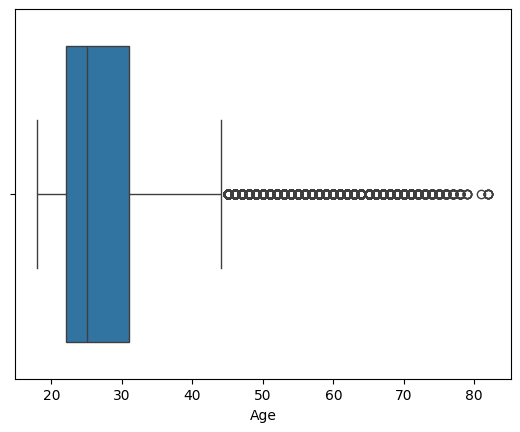

In [ ]:
# Age BoxPlot
sns.boxplot(data=pre, x='Age')

In [ ]:
# 기초통계량
pre['Age'].describe()

count    523888.000000
mean         27.733594
std           8.737248
min          18.000000
25%          22.000000
50%          25.000000
75%          31.000000
max          82.000000
Name: Age, dtype: float64

In [ ]:
# # 이상치 제거 함수 만들기
# def outlier_rm(data, col):
#     Q1 = data[col].quantile(0.25)
#     Q3 = data[col].quantile(0.75)
#     IQR = Q3 - Q1
#     high_bounded = Q3 + 1.5*IQR
#     low_bounded = Q1 - 1.5*IQR
#     return_df = data[
#         (pre[col] <= high_bounded) &
#         (pre[col] >= low_bounded) 
#         ]
#     return return_df

In [ ]:
# tmp = outlier_rm(pre,'Age')
# tmp.describe()

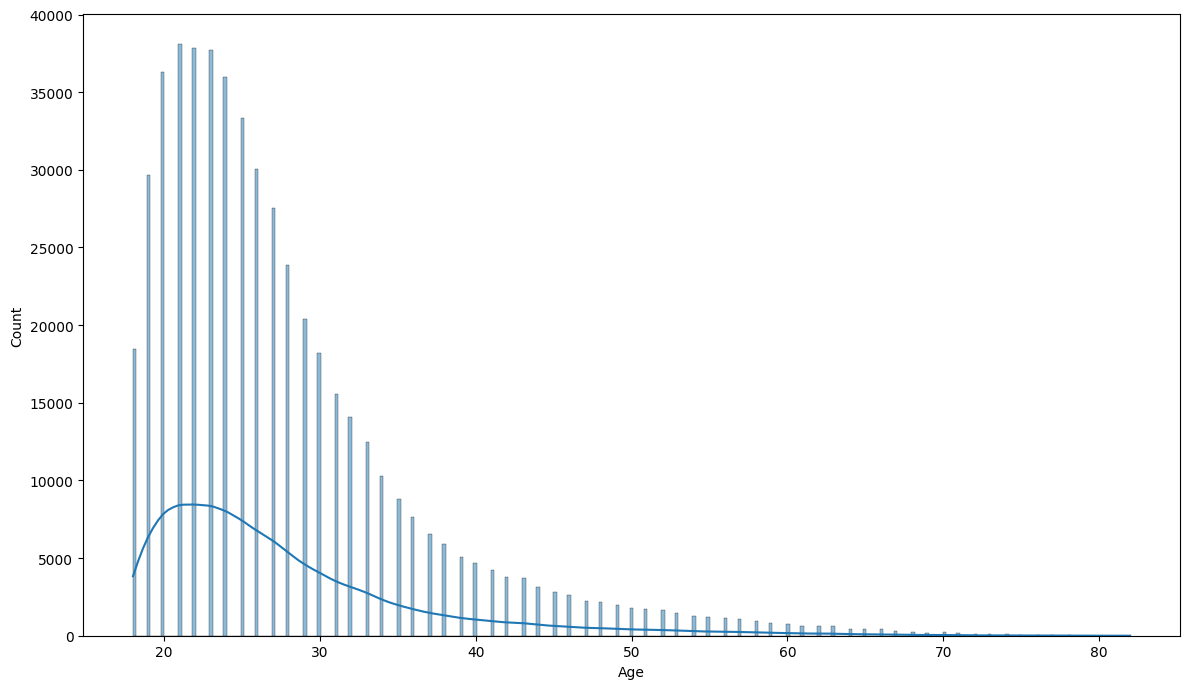

In [ ]:
# Age 분포 시각화
plt.figure(figsize=(12,7))
sns.histplot(data=pre, x='Age', kde='True')
plt.tight_layout()
plt.show()

In [ ]:
# 결측치 개수, 비율
pd.DataFrame({
    'sum': pre.isna().sum(),
    'ratio': pre.isna().mean() * 100
}).sort_values('ratio', ascending=False)

,sum,ratio
incomplete_flag,524351,84.505546
nplay_video,441976,71.229812
nchapters,251621,40.551787
nevents,192264,30.985684
last_event_DI,172521,27.803859
ndays_act,156786,25.267972
LoE_DI,105626,17.022916
Age,96605,15.569072
gender,86806,13.989844
grade,46770,7.537555


In [ ]:
# 결측치 개수, 비율
pd.DataFrame({
    'sum': pre.isna().sum(),
    'ratio': pre.isna().mean() * 100
}).sort_values('ratio', ascending=False)

,sum,ratio
incomplete_flag,524351,84.505546
nplay_video,441976,71.229812
nchapters,251621,40.551787
nevents,192264,30.985684
last_event_DI,172521,27.803859
ndays_act,156786,25.267972
LoE_DI,105626,17.022916
Age,96605,15.569072
gender,86806,13.989844
grade,46770,7.537555


In [ ]:
# 범주형
# print(pre['registered'].value_counts())
# print(pre['viewed'].value_counts())
# print(pre['explored'].value_counts())
# print(pre['certified'].value_counts())
# print(pre['LoE_DI'].value_counts())
# print(pre['final_cc_cname_DI'].value_counts()) #일단 보류
# print(pre['YoB'].value_counts().sort_index())
# print(pre['incomplete_flag'].value_counts().sort_index())


In [ ]:
# for col in pre.select_dtypes(include='float').columns:
#     plt.figure(figsize=(12,7))
#     sns.histplot(data=pre, x=col, kde=True)
#     plt.tight_layout()
#     plt.show()

In [ ]:
pre['incomplete_flag'] = pre['incomplete_flag'].fillna(0)

print("pre['incomplete_flag'] == 1 일 때 결측치 비율")
display(pre[pre['incomplete_flag'] == 1].isna().mean().sort_values(ascending=False))
print("pre['incomplete_flag'] == 0 일 때 결측치 비율")
display(pre[pre['incomplete_flag'] == 0].isna().mean().sort_values(ascending=False))

pre['incomplete_flag'] == 1 일 때 결측치 비율


nevents              1.000000
nplay_video          0.979790
last_event_DI        0.851647
activity_period      0.851647
ndays_act            0.630983
nchapters            0.280346
LoE_DI               0.175605
Age                  0.150382
gender               0.135144
grade                0.044174
userid_DI            0.000000
course_id            0.000000
viewed               0.000000
registered           0.000000
certified            0.000000
explored             0.000000
start_time_DI        0.000000
final_cc_cname_DI    0.000000
incomplete_flag      0.000000
nforum_posts         0.000000
Age_missing          0.000000
step                 0.000000
dtype: float64

pre['incomplete_flag'] == 0 일 때 결측치 비율


nplay_video          0.663252
nchapters            0.428469
ndays_act            0.183316
nevents              0.183316
activity_period      0.172865
last_event_DI        0.172865
LoE_DI               0.169244
Age                  0.156664
gender               0.140770
grade                0.081096
userid_DI            0.000000
course_id            0.000000
viewed               0.000000
registered           0.000000
certified            0.000000
explored             0.000000
start_time_DI        0.000000
final_cc_cname_DI    0.000000
incomplete_flag      0.000000
nforum_posts         0.000000
Age_missing          0.000000
step                 0.000000
dtype: float64

In [ ]:
display(pre[pre['incomplete_flag'] == 1][['nplay_video', 'nchapters','ndays_act']].head(100))

,nplay_video,nchapters,ndays_act
0,NaN,NaN,9.0
1,NaN,1.0,9.0
2,NaN,NaN,16.0
3,NaN,NaN,16.0
4,NaN,NaN,16.0
6,NaN,NaN,16.0
9,NaN,3.0,12.0
13,NaN,2.0,2.0
17,NaN,1.0,11.0
19,NaN,1.0,NaN


In [ ]:
pre.groupby('incomplete_flag')['certified'].mean()

incomplete_flag
0.0    0.032745
1.0    0.000125
Name: certified, dtype: float64